In [16]:
import numpy as np
import trimesh
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [17]:
source_filepath = 'data/surfaces/igea-compare/igea500-degree3.obj'
target_filepath = 'data/surfaces/igea-compare/target.off'

#source_filepath = 'data/surfaces/bob500-inv-exp-compare/gausscurv.ply'
#target_filepath = 'data/surfaces/bob500-inv-exp-compare/bob.obj'

#source_filepath = 'data/surfaces/fertility500-inv-exp/fertility-inv-exp.ply'
#target_filepath = 'data/surfaces/fertility500-inv-exp/fertility-target.ply'


source_mesh = trimesh.load( source_filepath, process=False)
target_mesh = trimesh.load( target_filepath, process=False)


# Normalize target to a [-0.9, 0.9] bounding box: center on its bbox
# center, then uniformly scale so the largest bbox dimension spans
# [-0.9, 0.9].
target_verts = np.asarray(target_mesh.vertices)
bbox_min = np.min(target_verts, axis=0)
bbox_max = np.max(target_verts, axis=0)
center = (bbox_min + bbox_max) / 2
scale = 1.8 / np.max(bbox_max - bbox_min)
target_mesh.vertices = (target_verts - center) * scale

# Rescale both meshes by the inverse of the target mesh's bounding box
# diagonal length, so that diagonal has unit length.
target_verts = np.asarray(target_mesh.vertices)
bbox_min = np.min(target_verts, axis=0)
bbox_max = np.max(target_verts, axis=0)
diagonal_length = np.sqrt(np.sum((bbox_max - bbox_min) ** 2))
source_mesh.vertices = np.asarray(source_mesh.vertices) / diagonal_length
target_mesh.vertices = target_verts / diagonal_length




In [18]:
# Symmetric point-to-surface distance between source and target: sample
# the same number of points on each mesh's surface, measure each sample's
# distance to the *other* mesh's surface, and average in each direction.
n_samples = 100_000

def closest_surface_distances(query_points, mesh):
    """Unsigned distance from each query point to the surface of `mesh`."""
    scene = o3d.t.geometry.RaycastingScene()
    mesh_t = o3d.t.geometry.TriangleMesh(
        o3d.core.Tensor(np.asarray(mesh.vertices), dtype=o3d.core.Dtype.Float32),
        o3d.core.Tensor(np.asarray(mesh.faces), dtype=o3d.core.Dtype.UInt32),
    )
    scene.add_triangles(mesh_t)
    return scene.compute_distance(
        o3d.core.Tensor(query_points.astype(np.float32))
    ).numpy()

source_samples, _ = trimesh.sample.sample_surface(source_mesh, n_samples)
target_samples, _ = trimesh.sample.sample_surface(target_mesh, n_samples)

source_to_target = closest_surface_distances(np.asarray(source_samples), target_mesh)
target_to_source = closest_surface_distances(np.asarray(target_samples), source_mesh)

mean_source_to_target = source_to_target.mean()
mean_target_to_source = target_to_source.mean()
symmetric_distance = (mean_source_to_target + mean_target_to_source) / 2

print(f"mean source -> target distance: {mean_source_to_target:.5f}")
print(f"mean target -> source distance: {mean_target_to_source:.5f}")
print(f"symmetric point-to-surface distance: {symmetric_distance:.5f}")

mean source -> target distance: 0.00031
mean target -> source distance: 0.00032
symmetric point-to-surface distance: 0.00031


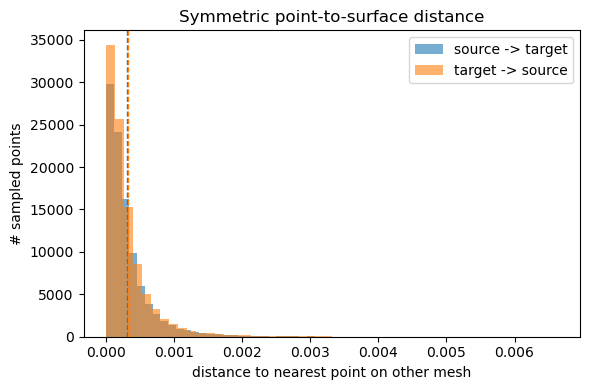

In [19]:
# Histogram of the point-to-surface distances in each direction
plt.figure(figsize=(6, 4))
plt.hist(source_to_target, bins=50, alpha=0.6, label='source -> target')
plt.hist(target_to_source, bins=50, alpha=0.6, label='target -> source')
plt.axvline(mean_source_to_target, color='C0', linestyle='--', linewidth=1)
plt.axvline(mean_target_to_source, color='C1', linestyle='--', linewidth=1)
plt.xlabel('distance to nearest point on other mesh')
plt.ylabel('# sampled points')
plt.title('Symmetric point-to-surface distance')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Interactive open3d view of both meshes together, source in blue and
# target in gray. Opens a window you can freely orbit.
source_o3d = o3d.geometry.TriangleMesh(
    o3d.utility.Vector3dVector(np.asarray(source_mesh.vertices)),
    o3d.utility.Vector3iVector(np.asarray(source_mesh.faces)),
)
source_o3d.paint_uniform_color([0.2, 0.4, 0.8])
source_o3d.compute_vertex_normals()

target_o3d = o3d.geometry.TriangleMesh(
    o3d.utility.Vector3dVector(np.asarray(target_mesh.vertices)),
    o3d.utility.Vector3iVector(np.asarray(target_mesh.faces)),
)
target_o3d.paint_uniform_color([0.7, 0.7, 0.7])
target_o3d.compute_vertex_normals()

o3d.visualization.draw_geometries(
    [source_o3d, target_o3d], mesh_show_back_face=True
)